# 03 Final RAGAS Evaluation and Method Selection

Notebook này mới chọn phương pháp cuối cùng:

- Đọc retrieval candidates/context từ notebook 02.
- Sinh hoặc load answer cache cho top retrieval candidates.
- Chạy RAGAS answer metrics thật khi còn key/quota; nếu thiếu quota thì dùng cache hợp lệ và ghi rõ cached.
- Kết hợp retrieval score + answer score bằng công thức cố định để chọn final method.

In [1]:
from pathlib import Path
from typing import Any
from collections import defaultdict
import hashlib
import itertools
import json
import math
import os
import time
import warnings

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib-cache"))

import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
import pandas as pd
from datasets import Dataset
from dotenv import load_dotenv
from IPython.display import Image, Markdown, display
from ragas import evaluate
from ragas.run_config import RunConfig

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
RAGAS_QUESTIONS_JSON = REPORTS_DIR / "ragas_questions.json"
RETRIEVAL_JSON = REPORTS_DIR / "retrieval_evaluation.json"
RAG_ANSWERS_JSON = REPORTS_DIR / "rag_answers.json"
RAGAS_EVAL_JSON = REPORTS_DIR / "ragas_evaluation.json"
RAGAS_EVAL_MD = REPORTS_DIR / "ragas_evaluation.md"

DEFAULT_MODEL = "gemini-3.1-flash-lite"
DEFAULT_EMBEDDING_MODEL = "models/gemini-embedding-001"
EVALUATION_VERSION = "ragas_final_method_selection_v1"
FINALIST_COUNT = 2
TOP_K = 5
RAGAS_RPM_PER_KEY = 12

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
load_dotenv(PROJECT_ROOT / ".env")


def sanitize(value):
    if isinstance(value, dict):
        return {key: sanitize(item) for key, item in value.items()}
    if isinstance(value, list):
        return [sanitize(item) for item in value]
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value


def gemini_keys() -> list[str]:
    raw_values = [
        os.getenv("GOOGLE_API_KEY") or "",
        os.getenv("GEMINI_API_KEY") or "",
        os.getenv("GEMINI_API_KEYS") or "",
    ]
    keys, seen = [], set()
    for raw_value in raw_values:
        for key in raw_value.split(","):
            key = key.strip()
            if key and key not in seen:
                keys.append(key)
                seen.add(key)
    return keys


def is_quota_error(error: Exception) -> bool:
    message = str(error)
    return "429" in message or "RESOURCE_EXHAUSTED" in message or "quota" in message.lower()


class BatchGeminiClient:
    def __init__(self, api_keys: list[str] | None = None, model: str | None = None, rpm_limit: int = 12):
        self.api_keys = api_keys or gemini_keys()
        if not self.api_keys:
            raise ValueError("Set GEMINI_API_KEY or GEMINI_API_KEYS")
        self.model = model or DEFAULT_MODEL
        self.sleep_seconds = 60 / max(1, rpm_limit)
        self._key_cycle = itertools.cycle(self.api_keys)
        self._last_request_at = {api_key: 0.0 for api_key in self.api_keys}
        self._exhausted = set()

    def generate(self, prompt: str) -> str:
        from google import genai

        last_error = None
        available = [key for key in self.api_keys if key not in self._exhausted]
        for _ in range(max(1, len(available))):
            api_key = next(self._key_cycle)
            if api_key in self._exhausted:
                continue
            try:
                self._wait_for_rate_limit(api_key)
                client = genai.Client(api_key=api_key)
                response = client.models.generate_content(model=self.model, contents=prompt)
                return response.text or ""
            except Exception as exc:
                last_error = exc
                if is_quota_error(exc):
                    self._exhausted.add(api_key)
        raise RuntimeError(f"Gemini generation failed for available keys: {last_error}")

    def _wait_for_rate_limit(self, api_key: str) -> None:
        elapsed = time.monotonic() - self._last_request_at[api_key]
        wait_seconds = self.sleep_seconds - elapsed
        if wait_seconds > 0:
            time.sleep(wait_seconds)
        self._last_request_at[api_key] = time.monotonic()


C:\Users\Acer Nitro\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Retrieval Candidates

Notebook 03 không build retriever lại. Nó dùng contexts đã được notebook 02 lưu trong `reports/retrieval_evaluation.json`, tránh tốn RAM và đảm bảo đánh giá answer đúng trên cùng retrieval benchmark.

In [2]:
question_meta = json.loads(RAGAS_QUESTIONS_JSON.read_text(encoding="utf-8"))
questions = question_meta["items"]
retrieval_report = json.loads(RETRIEVAL_JSON.read_text(encoding="utf-8"))

if retrieval_report.get("selection_stage") != "retrieval_only_no_final_method":
    raise ValueError("Notebook 02 must write retrieval-only candidates before notebook 03 selects the final method.")

retrieval_summary = sorted(
    retrieval_report["summary"],
    key=lambda row: (row["retrieval_candidate_score"], row["mrr"], row["ndcg@5"]),
    reverse=True,
)
finalist_methods = [row["method"] for row in retrieval_summary[:FINALIST_COUNT]]
details_by_key = {(row["method"], row["question_id"]): row for row in retrieval_report["details"]}

display(pd.DataFrame([{k: question_meta.get(k) for k in ["generated_with_ragas", "candidate_target", "accepted_count"]}]))
display(Markdown(f"Finalists for answer evaluation: `{', '.join(finalist_methods)}`"))
pd.DataFrame(retrieval_summary)


,generated_with_ragas,candidate_target,accepted_count
0,True,40,30


Finalists for answer evaluation: `hybrid, bm25`

,method,recall@5,mrr,ndcg@5,lexical_context_precision,lexical_context_recall,citation_coverage,ragas_context_precision,ragas_context_recall,retrieval_candidate_score
0,hybrid,0.966667,0.966667,0.971033,0.513678,0.840638,1.0,0.0,0.0,0.532758
1,bm25,1.000000,0.975000,0.957600,0.578546,0.845141,1.0,0.0,0.0,0.531900
2,hybrid_rrf_mmr,0.966667,0.966667,0.939262,0.527128,0.845509,1.0,0.0,0.0,0.524816
3,hybrid_rrf,0.966667,0.966667,0.937824,0.530869,0.844814,1.0,0.0,0.0,0.524456
4,vector,1.000000,0.956667,0.931987,0.414802,0.709577,1.0,0.0,0.0,0.519997


## 2. Generate or Load Candidate Answers

In [3]:
SYSTEM_INSTRUCTION = """Bạn là trợ lý tra cứu pháp luật lao động Việt Nam.
Chỉ trả lời dựa trên CONTEXT. Nếu context không đủ, nói rõ là chưa đủ căn cứ.
Không đưa ra tư vấn pháp lý chắc chắn như luật sư. Luôn trích nguồn dạng [S1], [S2]."""


def retrieval_signature() -> str:
    payload = {
        "version": EVALUATION_VERSION,
        "top_k": retrieval_report.get("top_k"),
        "chunk_max_words": retrieval_report.get("chunk_max_words"),
        "chunk_overlap_words": retrieval_report.get("chunk_overlap_words"),
        "finalist_methods": finalist_methods,
        "details": [
            {
                "method": row["method"],
                "question_id": row["question_id"],
                "chunk_ids": [citation.get("chunk_id") for citation in row.get("citations", [])],
            }
            for row in retrieval_report["details"]
            if row["method"] in finalist_methods
        ],
    }
    return hashlib.sha1(json.dumps(payload, ensure_ascii=False, sort_keys=True).encode("utf-8")).hexdigest()


SIGNATURE = retrieval_signature()


def build_context(citations: list[dict], max_chars: int = 9000) -> tuple[str, list[dict]]:
    blocks, used_chars, kept = [], 0, []
    for idx, citation in enumerate(citations, start=1):
        label = f"S{idx}"
        block = f"[{label}] {citation.get('title') or ''}\n{citation.get('article') or ''}\n{(citation.get('text') or '').strip()}"
        if used_chars + len(block) > max_chars:
            break
        used_chars += len(block)
        blocks.append(block)
        kept.append({**citation, "label": label})
    return "\n\n".join(blocks), kept


def build_rag_prompt(question: str, citations: list[dict]) -> tuple[str, list[dict]]:
    context, kept = build_context(citations)
    prompt = f"""{SYSTEM_INSTRUCTION}

CONTEXT:
{context}

Câu hỏi: {question}

Trả lời ngắn gọn bằng tiếng Việt, có bullet nếu cần, và trích nguồn sau từng ý quan trọng."""
    return prompt, kept


def load_cached_answers() -> list[dict]:
    if not RAG_ANSWERS_JSON.exists():
        return []
    rows = json.loads(RAG_ANSWERS_JSON.read_text(encoding="utf-8"))
    return rows if isinstance(rows, list) else rows.get("answers", [])


def answer_cache_key(method: str, question_id: str) -> tuple[str, str, str]:
    return method, question_id, SIGNATURE


cached_answers = {
    answer_cache_key(row.get("retrieval_method"), row.get("id")): row
    for row in load_cached_answers()
    if row.get("answer_signature") == SIGNATURE
}

answer_rows, missing_prompts = [], []
for method in finalist_methods:
    for item in questions:
        detail = details_by_key[(method, item["id"])]
        prompt, citations = build_rag_prompt(item["question"], detail["citations"])
        cache_key = answer_cache_key(method, item["id"])
        cached = cached_answers.get(cache_key)
        if cached:
            answer_rows.append(cached)
            continue
        missing_prompts.append((method, item, prompt, citations, detail["contexts"]))

if missing_prompts:
    keys = gemini_keys()
    if not keys:
        raise RuntimeError("Gemini key is required when candidate answer cache is missing.")
    client = BatchGeminiClient(api_keys=keys, model=DEFAULT_MODEL, rpm_limit=RAGAS_RPM_PER_KEY)
    for method, item, prompt, citations, contexts in missing_prompts:
        answer_rows.append({
            "id": item["id"],
            "question": item["question"],
            "reference": item["reference"],
            "answer": client.generate(prompt),
            "contexts": contexts,
            "citations": citations,
            "retrieval_method": method,
            "answer_signature": SIGNATURE,
            "answer_backend": "gemini",
        })

answer_rows = sorted(answer_rows, key=lambda row: (finalist_methods.index(row["retrieval_method"]), row["id"]))
RAG_ANSWERS_JSON.write_text(json.dumps(sanitize(answer_rows), ensure_ascii=False, indent=2), encoding="utf-8")

pd.DataFrame([{
    "finalist_methods": ", ".join(finalist_methods),
    "answer_rows": len(answer_rows),
    "cached_answers": len(answer_rows) - len(missing_prompts),
    "new_answers": len(missing_prompts),
    "answer_signature": SIGNATURE,
}])


,finalist_methods,answer_rows,cached_answers,new_answers,answer_signature
0,"hybrid, bm25",60,60,0,aa28faaee5b3cddd5afdd73f3c4fa457fdd60ccf


## 3. RAGAS Answer Metrics

This section evaluates the generated answers for the finalist retrieval methods. The next section compares the candidates side by side before picking the final method.

In [4]:
def load_cached_ragas_report() -> dict:
    if not RAGAS_EVAL_JSON.exists():
        return {}
    data = json.loads(RAGAS_EVAL_JSON.read_text(encoding="utf-8"))
    return data if isinstance(data, dict) else {}


def select_available_gemini_key(keys: list[str]) -> str:
    from google import genai

    for key in keys:
        try:
            client = genai.Client(api_key=key)
            response = client.models.generate_content(model=DEFAULT_MODEL, contents="Return exactly: OK")
            if (getattr(response, "text", "") or "").strip():
                return key
        except Exception:
            continue
    raise RuntimeError("No Gemini key has available quota for RAGAS metrics.")


def build_llm_and_embeddings():
    keys = gemini_keys()
    if not keys:
        raise RuntimeError("Gemini key is required when cached RAGAS metrics are missing.")
    selected_key = select_available_gemini_key(keys)
    os.environ["GOOGLE_API_KEY"] = selected_key
    from langchain_core.rate_limiters import InMemoryRateLimiter
    from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings

    rate_limiter = InMemoryRateLimiter(requests_per_second=RAGAS_RPM_PER_KEY / 60, check_every_n_seconds=0.25, max_bucket_size=1)
    return (
        ChatGoogleGenerativeAI(
            model=DEFAULT_MODEL,
            google_api_key=selected_key,
            temperature=0,
            timeout=90,
            max_retries=0,
            rate_limiter=rate_limiter,
        ),
        GoogleGenerativeAIEmbeddings(model=DEFAULT_EMBEDDING_MODEL, google_api_key=selected_key),
    )


def answer_metrics():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", DeprecationWarning)
        from ragas.metrics import answer_correctness, answer_relevancy, context_precision, context_recall, faithfulness
    answer_relevancy.strictness = 1
    return [context_precision, context_recall, faithfulness, answer_relevancy, answer_correctness]


desired_metrics = ["context_precision", "context_recall", "faithfulness", "answer_relevancy", "answer_correctness"]
cached_report = load_cached_ragas_report()
valid_cache = (
    cached_report.get("evaluation_version") == EVALUATION_VERSION
    and cached_report.get("answer_signature") == SIGNATURE
    and cached_report.get("answer_count") == len(answer_rows)
)

if valid_cache and cached_report.get("details"):
    details = cached_report["details"]
    aggregate_by_method = cached_report["aggregate_by_method"]
    unavailable_metrics = cached_report.get("unavailable_metrics", [])
    metrics_cached = True
else:
    eval_rows = [
        {
            "user_input": row["question"],
            "response": row["answer"],
            "retrieved_contexts": row["contexts"],
            "reference": row["reference"],
        }
        for row in answer_rows
    ]
    dataset = Dataset.from_list(eval_rows)
    frame = pd.DataFrame([
        {
            **eval_row,
            "retrieval_method": answer_row["retrieval_method"],
            "question_id": answer_row["id"],
        }
        for eval_row, answer_row in zip(eval_rows, answer_rows)
    ])
    unavailable_metrics = []
    try:
        llm, embeddings = build_llm_and_embeddings()
        run_config = RunConfig(timeout=90, max_retries=0, max_wait=2, max_workers=1)
        for metric in answer_metrics():
            try:
                result = evaluate(dataset=dataset, metrics=[metric], llm=llm, embeddings=embeddings, run_config=run_config, show_progress=False)
                frame[metric.name] = result.to_pandas()[metric.name].reset_index(drop=True)
            except Exception as error:
                unavailable_metrics.append(metric.name)
                print(f"skip metric {metric.name}: {type(error).__name__}")
                if is_quota_error(error):
                    break
    except Exception as error:
        unavailable_metrics = desired_metrics.copy()
        print(f"RAGAS metrics unavailable: {type(error).__name__}")

    metric_cols = [metric for metric in desired_metrics if metric in frame and pd.notna(frame[metric]).any()]
    details = sanitize(frame.to_dict("records"))
    aggregate_by_method = {}
    for method, group in frame.groupby("retrieval_method"):
        aggregate_by_method[method] = {
            metric: float(group[metric].mean())
            for metric in metric_cols
            if metric in group and pd.notna(group[metric].mean())
        }
    unavailable_metrics = sorted(set(unavailable_metrics) | {metric for metric in desired_metrics if all(metric not in scores for scores in aggregate_by_method.values())})
    metrics_cached = False

pd.DataFrame(aggregate_by_method).T


,context_precision,context_recall
bm25,0.000000,NaN
hybrid,0.484444,0.666667


## 4. Comparison and Final Selection

In [5]:
def answer_score(metrics: dict) -> float | None:
    usable = [value for key, value in metrics.items() if key in ["context_precision", "context_recall", "faithfulness", "answer_relevancy"] and value is not None]
    if not usable:
        return None
    weights = {
        "context_precision": 0.20,
        "context_recall": 0.20,
        "faithfulness": 0.35,
        "answer_relevancy": 0.25,
    }
    present_weight = sum(weight for metric, weight in weights.items() if metric in metrics and metrics[metric] is not None)
    return sum(metrics.get(metric, 0.0) * weight for metric, weight in weights.items()) / max(present_weight, 1e-12)


retrieval_by_method = {row["method"]: row for row in retrieval_summary}
final_rows = []
for method in finalist_methods:
    retrieval_score = retrieval_by_method[method]["retrieval_candidate_score"]
    metrics = aggregate_by_method.get(method, {})
    method_answer_score = answer_score(metrics)
    final_score = retrieval_score if method_answer_score is None else 0.45 * retrieval_score + 0.55 * method_answer_score
    final_rows.append({
        "method": method,
        "retrieval_candidate_score": retrieval_score,
        "answer_score": method_answer_score,
        "final_score": final_score,
        **{f"ragas_{metric}": metrics.get(metric) for metric in desired_metrics},
    })

final_df = pd.DataFrame(final_rows).sort_values("final_score", ascending=False)
selected_method = final_df.iloc[0]["method"]

ragas_report = {
    "backend": "ragas_evaluate",
    "evaluation_version": EVALUATION_VERSION,
    "model": DEFAULT_MODEL,
    "cached": metrics_cached,
    "answers_cached": len(missing_prompts) == 0,
    "metrics_cached": metrics_cached,
    "answer_count": len(answer_rows),
    "answer_signature": SIGNATURE,
    "retrieval_methods_evaluated": finalist_methods,
    "selected_method": selected_method,
    "selection_formula": "final_score = 0.45 * retrieval_candidate_score + 0.55 * answer_score",
    "aggregate_by_method": aggregate_by_method,
    "selection_table": final_df.to_dict("records"),
    "unavailable_metrics": unavailable_metrics,
    "details": details,
}
RAGAS_EVAL_JSON.write_text(json.dumps(sanitize(ragas_report), ensure_ascii=False, indent=2), encoding="utf-8")
final_df


,method,retrieval_candidate_score,answer_score,final_score,ragas_context_precision,ragas_context_recall,ragas_faithfulness,ragas_answer_relevancy,ragas_answer_correctness
0,hybrid,0.532758,0.575556,0.556297,0.484444,0.666667,None,None,None
1,bm25,0.531900,0.000000,0.239355,0.000000,NaN,None,None,None


### final_method_selection.png

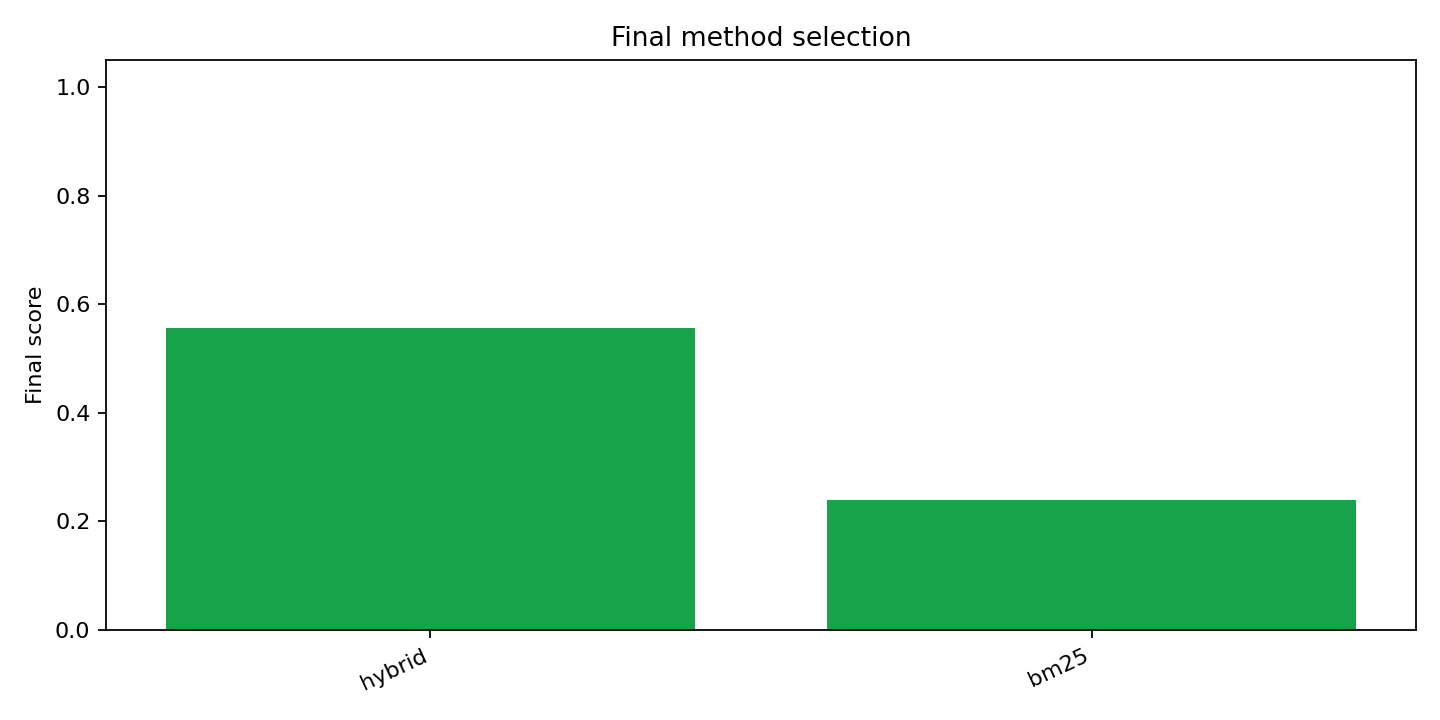

### final_score_breakdown.png

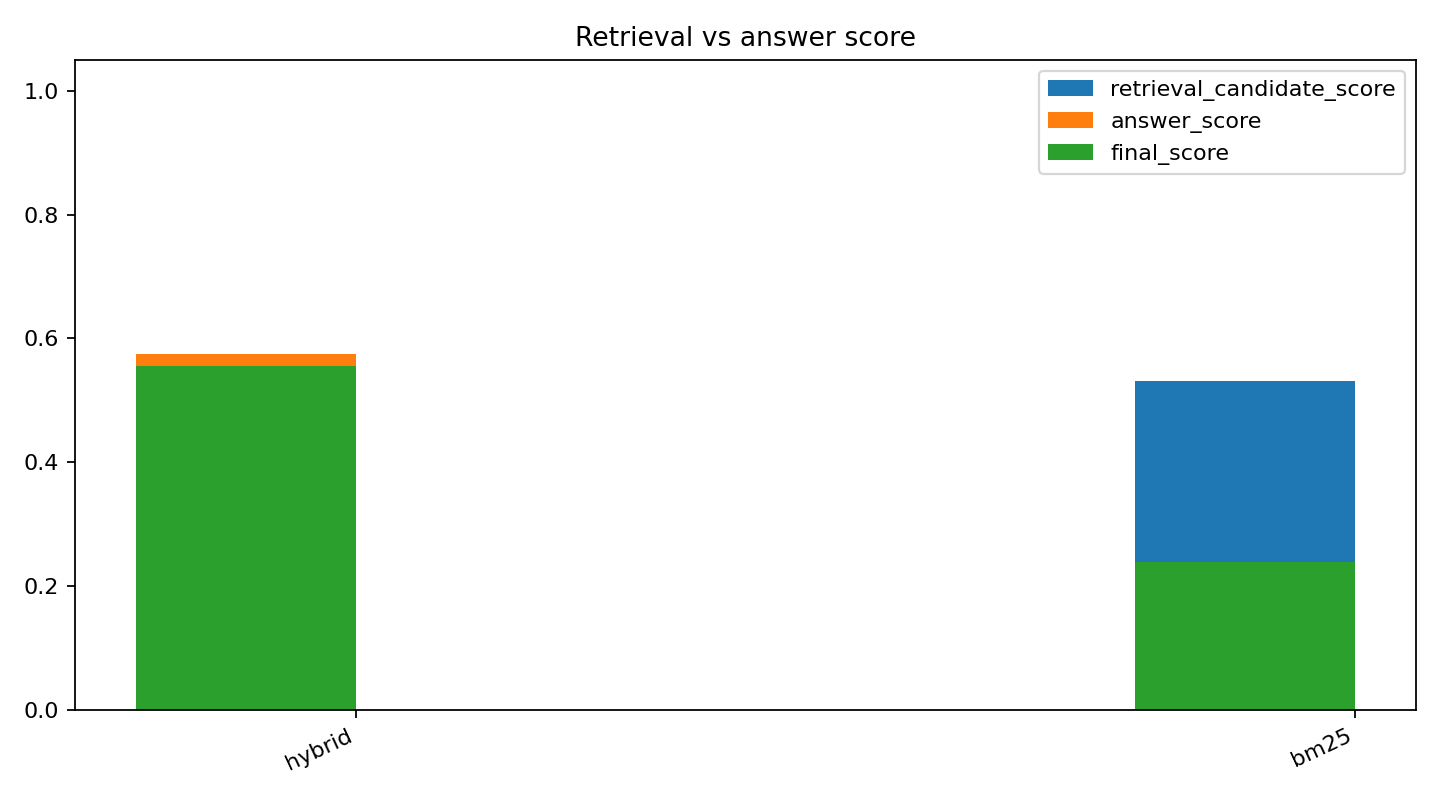

### ragas_per_question_heatmap.png

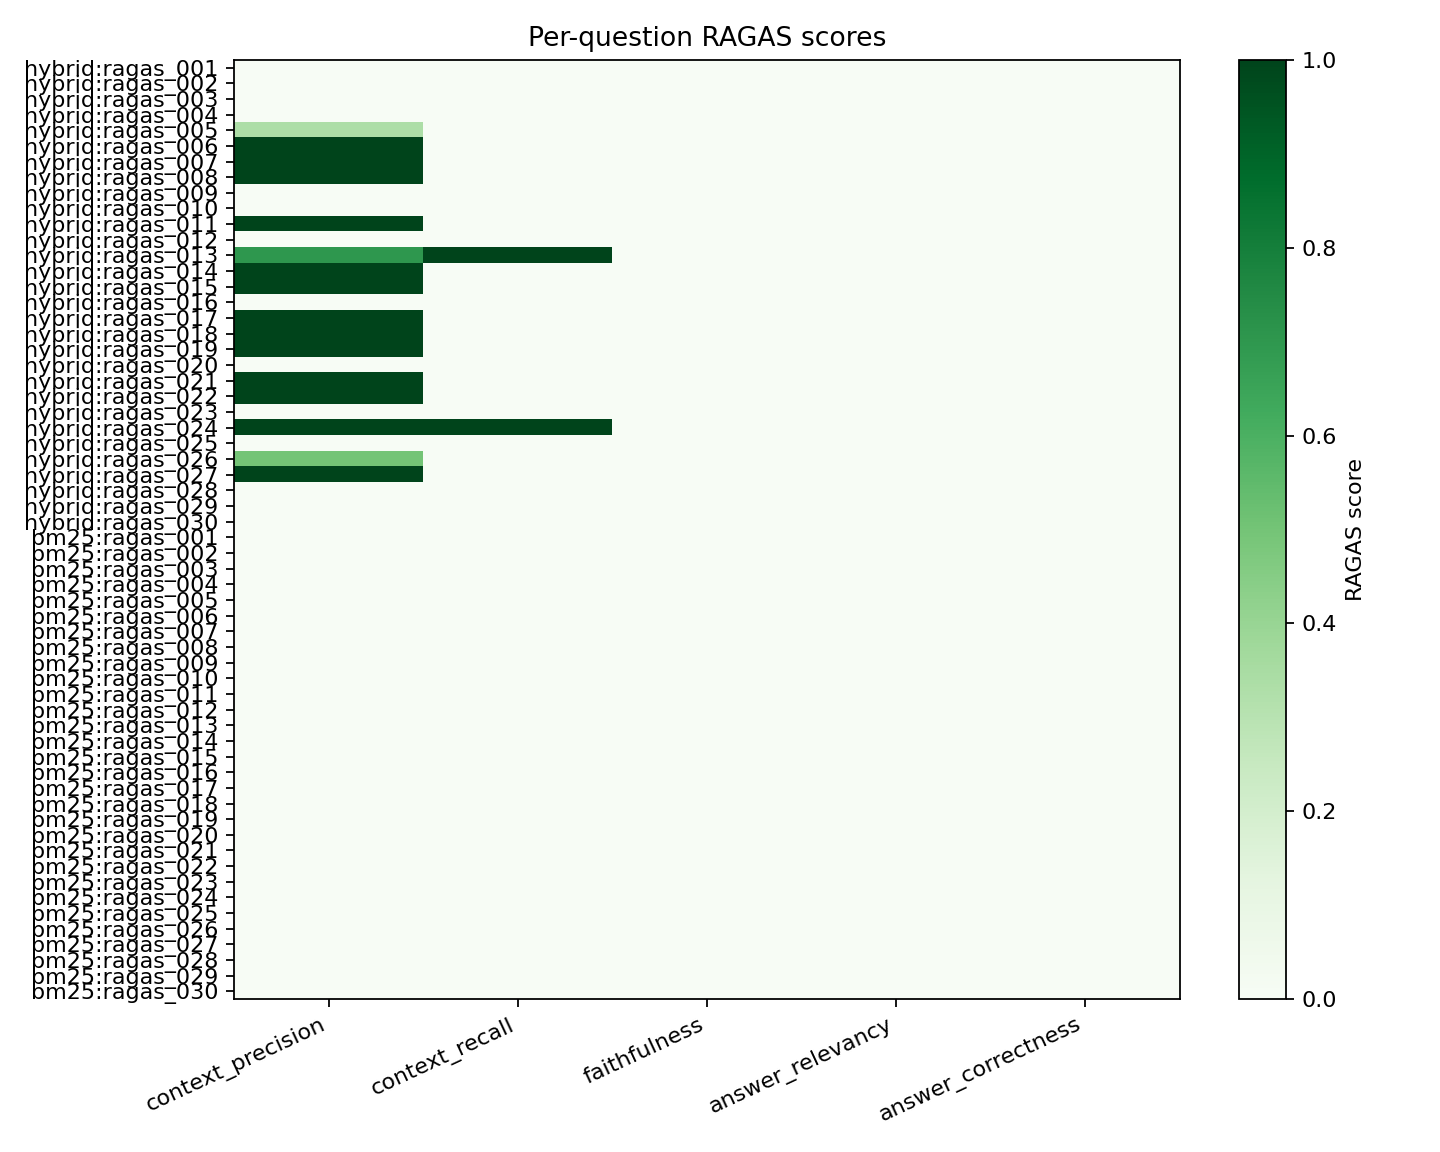

In [6]:
plot_df = final_df.sort_values("final_score", ascending=False)
plt.figure(figsize=(9, 4.5))
plt.bar(plot_df["method"], plot_df["final_score"], color="#16a34a")
plt.ylim(0, 1.05)
plt.ylabel("Final score")
plt.title("Final method selection")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_method_selection.png", dpi=160)
plt.close()

metric_columns = [col for col in ["retrieval_candidate_score", "answer_score", "final_score"] if col in final_df]
plt.figure(figsize=(9, 5))
for idx, metric in enumerate(metric_columns):
    plt.bar(
        range(len(final_df)),
        final_df[metric].fillna(0),
        width=0.22,
        label=metric,
        align="edge",
    )
plt.xticks([idx + 0.22 for idx in range(len(final_df))], final_df["method"], rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.title("Retrieval vs answer score")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_score_breakdown.png", dpi=160)
plt.close()

details_df = pd.DataFrame(details)
available_detail_metrics = [metric for metric in desired_metrics if metric in details_df]
if available_detail_metrics:
    heatmap_df = details_df[["retrieval_method", "question_id", *available_detail_metrics]].copy()
    heatmap_df["row"] = heatmap_df["retrieval_method"] + ":" + heatmap_df["question_id"]
    numeric_scores = heatmap_df[available_detail_metrics].apply(pd.to_numeric, errors="coerce").fillna(0)
    plt.figure(figsize=(9, max(6, len(heatmap_df) * 0.12)))
    plt.imshow(numeric_scores.to_numpy(dtype=float), aspect="auto", cmap="Greens", vmin=0, vmax=1)
    plt.colorbar(label="RAGAS score")
    plt.xticks(range(len(available_detail_metrics)), available_detail_metrics, rotation=25, ha="right")
    plt.yticks(range(len(heatmap_df)), heatmap_df["row"])
    plt.title("Per-question RAGAS scores")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "ragas_per_question_heatmap.png", dpi=160)
    plt.close()

for name in ["final_method_selection.png", "final_score_breakdown.png", "ragas_per_question_heatmap.png"]:
    path = FIGURES_DIR / name
    if path.exists():
        display(Markdown(f"### {name}"))
        display(Image(filename=str(path)))


In [7]:
lines = [
    "# RAGAS Answer Evaluation and Final Selection",
    "",
    "## Comparison",
    "",
    "The table below compares the finalist retrieval methods after generation. The final method is chosen only after looking at retrieval score, answer score, and the combined final score.",
    "",
    f"- Backend: `{ragas_report['backend']}`",
    f"- Cached metrics used: `{ragas_report.get('metrics_cached', False)}`",
    f"- Answers cached: `{ragas_report.get('answers_cached', False)}`",
    f"- Answers evaluated: `{ragas_report['answer_count']}`",
    f"- Retrieval methods evaluated: `{', '.join(ragas_report['retrieval_methods_evaluated'])}`",
    f"- Selected final method: `{ragas_report['selected_method']}`",
    f"- Selection formula: `{ragas_report['selection_formula']}`",
    "",
    "| Rank | Method | Retrieval score | Answer score | Final score |",
    "|---:|---|---:|---:|---:|",
]
for rank, row in enumerate(final_df.to_dict("records"), start=1):
    answer_value = "n/a" if row.get("answer_score") is None else f"{row['answer_score']:.3f}"
    lines.append(f"| {rank} | {row['method']} | {row['retrieval_candidate_score']:.3f} | {answer_value} | {row['final_score']:.3f} |")

lines.extend(["", "## RAGAS Metrics", "", "| Method | Metric | Score |", "|---|---|---:|"])
for method, metrics in aggregate_by_method.items():
    for metric, value in metrics.items():
        lines.append(f"| {method} | {metric} | {value:.3f} |")
for metric in ragas_report.get("unavailable_metrics", []):
    lines.append(f"| all | {metric} | unavailable |")

lines.extend([
    "",
    "## Figures",
    "",
    "- `reports/figures/final_method_selection.png`",
    "- `reports/figures/final_score_breakdown.png`",
    "- `reports/figures/ragas_per_question_heatmap.png`",
    "",
    "## Weakest Cases",
    "",
])
details_df = pd.DataFrame(details)
available_detail_metrics = [metric for metric in desired_metrics if metric in details_df]
if available_detail_metrics:
    details_df["mean_score"] = details_df[available_detail_metrics].apply(pd.to_numeric, errors="coerce").mean(axis=1)
    for _, row in details_df.sort_values("mean_score").head(8).iterrows():
        question = row.get("user_input") or row.get("question") or ""
        lines.append(f"- `{row.get('retrieval_method')}` - {question} - mean={row['mean_score']:.3f}")
else:
    lines.append("- RAGAS detail metrics unavailable because Gemini quota was unavailable for evaluation.")

RAGAS_EVAL_MD.write_text("\n".join(lines) + "\n", encoding="utf-8")
Markdown(f"**Selected final method:** `{selected_method}`")


**Selected final method:** `hybrid`